In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import ultranest
import corner

from utils.parse_data import *

In [2]:
#%matplotlib widget
#plt.close('all')

In [3]:
# Leggiamo il file di dati:
data = read_file("mass.mas20.txt")
data = extract_relevant_data(data)

print(data.head())
# data sarà in formato dataframe di pandas. La BE è già per nucleone ed è in unità keV.
# Nota che per convenzione la BE si divide appunto per il numero di nucleoni A, e non per la più precisa massa atomica.
# Anche nei modelli che useremo appare A invece della massa atomica. Per questo motivo, carichiamo A ma non la massa atomica.

   A  Z  N  el  binding_energy  binding_energy_err
0  1  0  1   n         0.00000             0.00000
1  1  1  0   H         0.00000             0.00000
2  2  1  1   H      1112.28310             0.00020
3  3  1  2   H      2827.26540             0.00030
4  3  2  1  He      2572.68044             0.00015


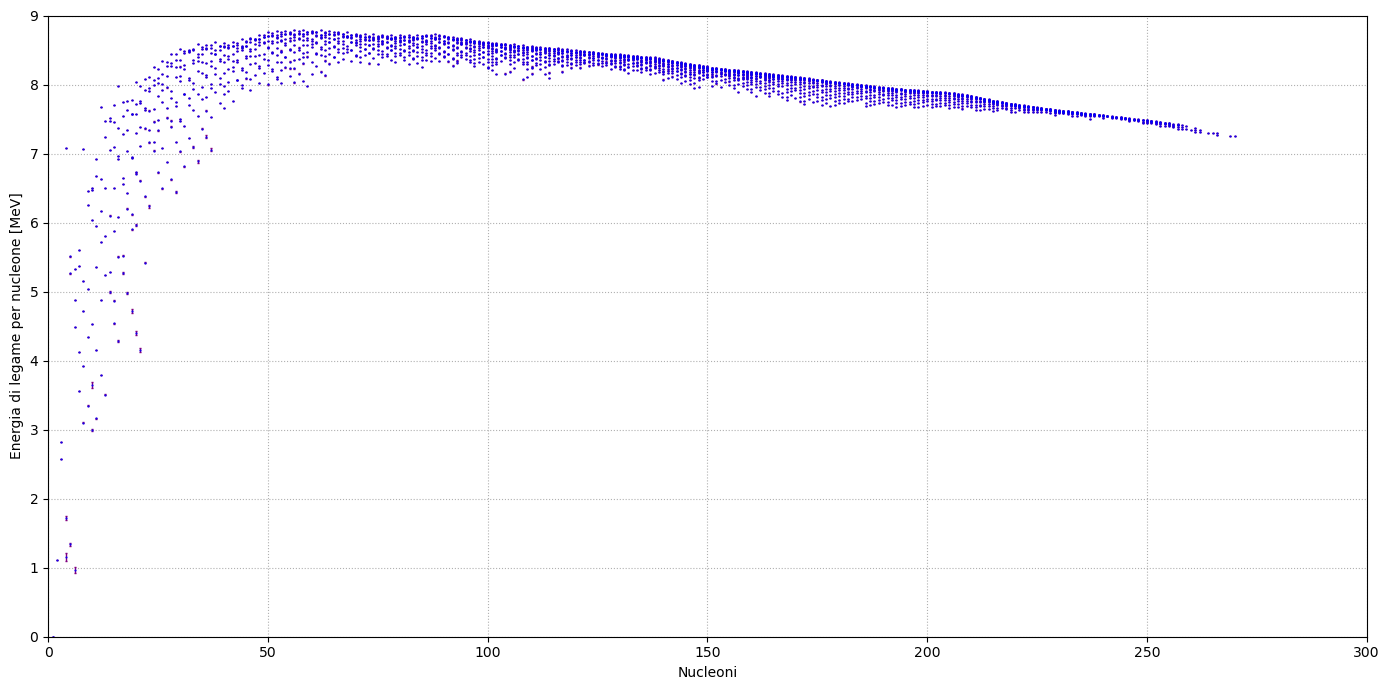

In [4]:
# Grafichiamo i dati per controllare sia tutto apposto:

plt.figure(figsize = (14,7))
plt.errorbar(data["A"], data["binding_energy"]*1e-3, yerr = data["binding_energy_err"]*1e-3,
             fmt = ".", ms=1, color="b", elinewidth=1, ecolor = "purple", capsize = 1)
#plt.title("Energia di legame per nucleone")
plt.xlabel("Nucleoni")
plt.ylabel("Energia di legame per nucleone [MeV]")
plt.xlim(0,300)
plt.ylim(0,9)
plt.grid(linestyle = ":")
plt.tight_layout()
plt.show()
# Chiaramente per ciascun A ci sono varie possibili combinazioni di protoni e nucleoni, e quindi vari punti in generale.
# Qui sono graficate anche le barre di errore, ma sono incredibilmente piccole.

# Ultranest per forma base (senza pairing)

In [29]:
# Per ottimizzare un po' la run, tutto quello che possiamo calcolare in anticipo lo calcoliamo in anticipo.
# Questo include il trasformare colonne del dataframe in array, così da non richiamare pandas dentro la likelihood.

A = data["A"].to_numpy(dtype=float)
Z = data["Z"].to_numpy(dtype=float)
N = data["N"].to_numpy(dtype=float)
BE = data["binding_energy"].to_numpy(dtype=float) * 1e-3
sigma_exp_sq = (data["binding_energy_err"].to_numpy(dtype=float) * 1e-3)**2

A23 = A**(2/3)
A13 = A**(1/3)
ZZ = Z*(Z-1) / A13
NZ = (N-Z)**2 / A
ln_2pi = np.log(2*np.pi)
# Ricorda bene che tutte le cose definite fuori qui fuori dalle funzioni sono a scope globale: questa è prassi standard per ultranest.


# Indichiamo qui i bounds dei nostri prior:
lower_bounds = np.array([0, 0, 0, 0, 0], dtype=float)
upper_bounds = np.array([1, 1, 1, 1, 1], dtype=float)
# Nota che per costruzione del modello i lower bound non possono mai essere negativi! (eccezione per ln_epsilon, chiaramente)

################################################################
# Sono partito usando:                                         #
# lower_bounds = np.array([0, 0, 0, 0, -6], dtype=float)       #
# upper_bounds = np.array([30, 30, 30, 30, 4], dtype=float)    #
# ma qualsiasi run preliminare riduceva tutti i prior a [0,1], #
# quindi li ho aggiornati (anche se sembrano più sbagliati)    #
################################################################

# E ora scriviamo likelihood e prior con la sintassi di ultranest vettorizzata:

def ln_likelihood_base(parameters):
    # Nella implementazione vettorizzata, parameters non è solo un array di 5 elementi, bensì un array di array di 5 elementi.
    # Il primo indice si riferisce dunque al live point in questione, mentre il secondo indice ai suoi parametri.
    
    # Spacchetta i parametri, incluso il rumore:
    aV = parameters[:, 0]
    aS = parameters[:, 1]
    aC = parameters[:, 2]
    aA = parameters[:, 3]
    ln_eps = parameters[:, 4]

    # Aggiungi il rumore all'errore sperimentale:
    sigma_teo_sq = np.exp(2.0*ln_eps)
    sigma_tot_sq = sigma_exp_sq[None, :] + sigma_teo_sq[:, None]
    # L'errore sperimentale è indipendente dal live point, mentre il rumore teorico è indipendente dal dato.
    # Nota che ci aspettiamo che l'errore sperimentale sia minuscolo e praticamente contribuisca solo il rumore teorico:
    # il senso fisico di questa cosa è che ci aspettiamo l'accuratezza del modello sia molto peggiore dell'accuratezza sperimentale!

    # Calcoliamo il valore previsto teorico:
    model = aV[:,None] * A - aS[:,None] * A23 - aC[:,None] * ZZ - aA[:,None] * NZ

    # Presumiamo, come sempre, distribuzioni normali e misure indipendenti:
    return -0.5 * np.sum( ln_2pi + np.log(sigma_tot_sq) + (BE[None,:] - model)**2.0 / sigma_tot_sq , axis=1)


def prior_base(cube):
    # Sfruttando i bounds definiti fuori, scriviamo in un colpo solo:
    return cube * (upper_bounds - lower_bounds) + lower_bounds


In [30]:
# Svolgiamo la run per il caso base:

list_of_params = ["aV", "aS", "aC", "aA", "ln_epsilon"]
sampler = ultranest.ReactiveNestedSampler(list_of_params, ln_likelihood_base, prior_base, vectorized=True)
result_base = sampler.run()

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-5e+03  982.74 [-4983.1531..-4983.1530]*| it/evals=13160/52975 eff=25.0309% N=400   0     00  
[ultranest] Likelihood function evaluations: 53035
[ultranest]   logZ = -5011 +- 0.1796
[ultranest] Effective samples strategy satisfied (ESS = 2523.7, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
[ultranest]   logZ error budget: single: 0.25 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.


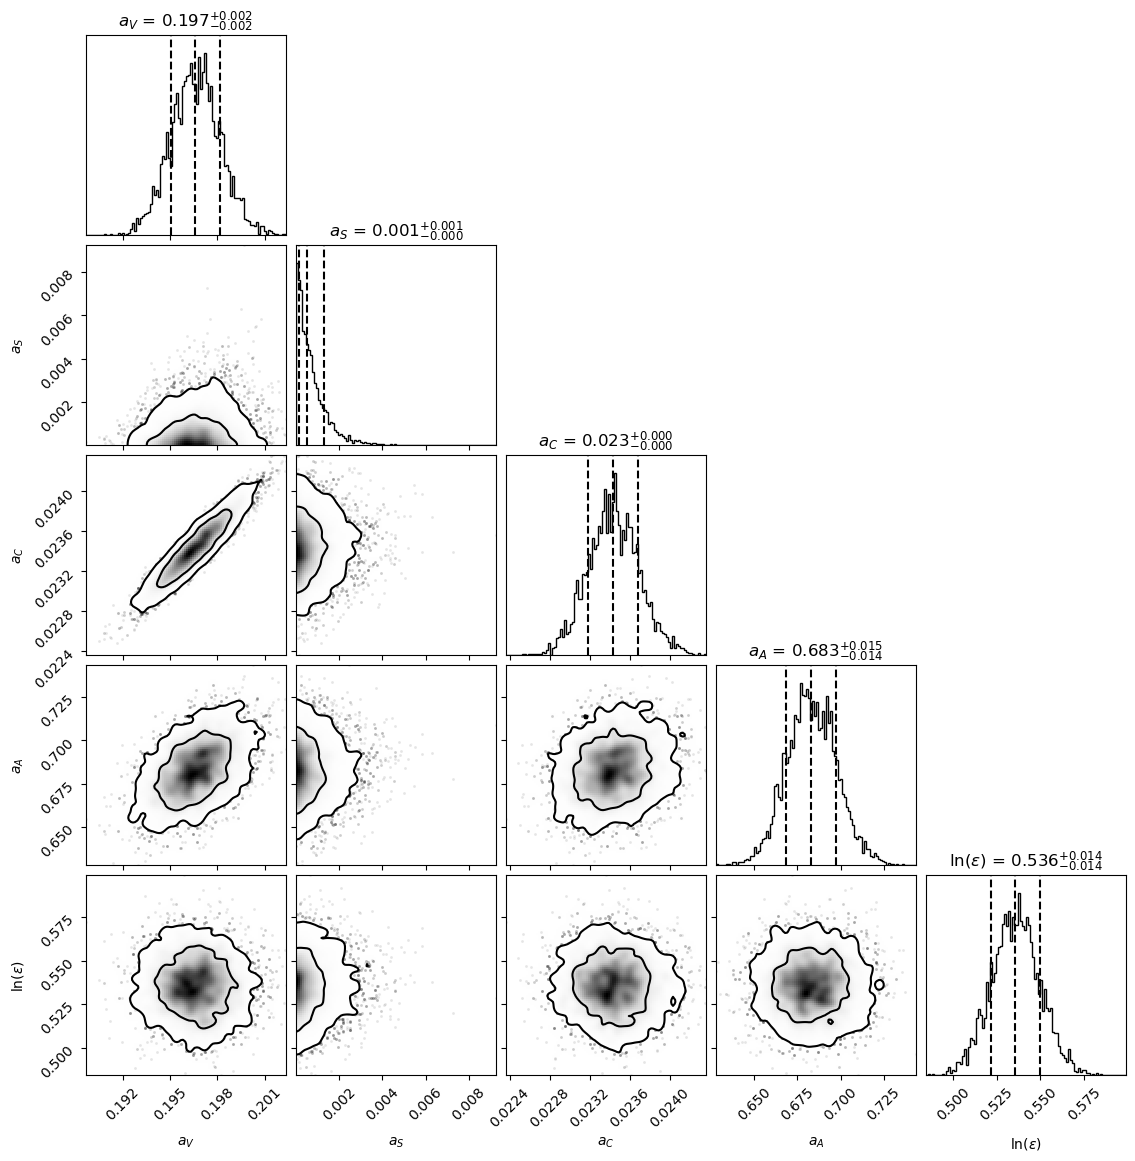

In [31]:
# Facciamo i corner plot per farci un'idea della situazione:

samples_base = result_base["samples"]
labels = [r"$a_V$", r"$a_S$", r"$a_C$", r"$a_A$", r"$\ln (\epsilon)$"]

figure = corner.corner(
    samples_base,
    labels=labels,
    show_titles=True,           
    title_kwargs={"fontsize": 12},
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84],   
    plot_datapoints=True,
    bins=100,
    smooth=2.0,
    levels=(0.68, 0.95)
    #fill_contours=True,        
    #color="royalblue"                
)

axes = figure.axes

# Già dall'evoluzione di ultranest ci rendevamo conto che aS satura al lower bound, ma il punto è che un aS negativo non avrebbe senso fisico.
# Alternativamente, il modello base funziona bene solo presumendo che aS tenda a zero.

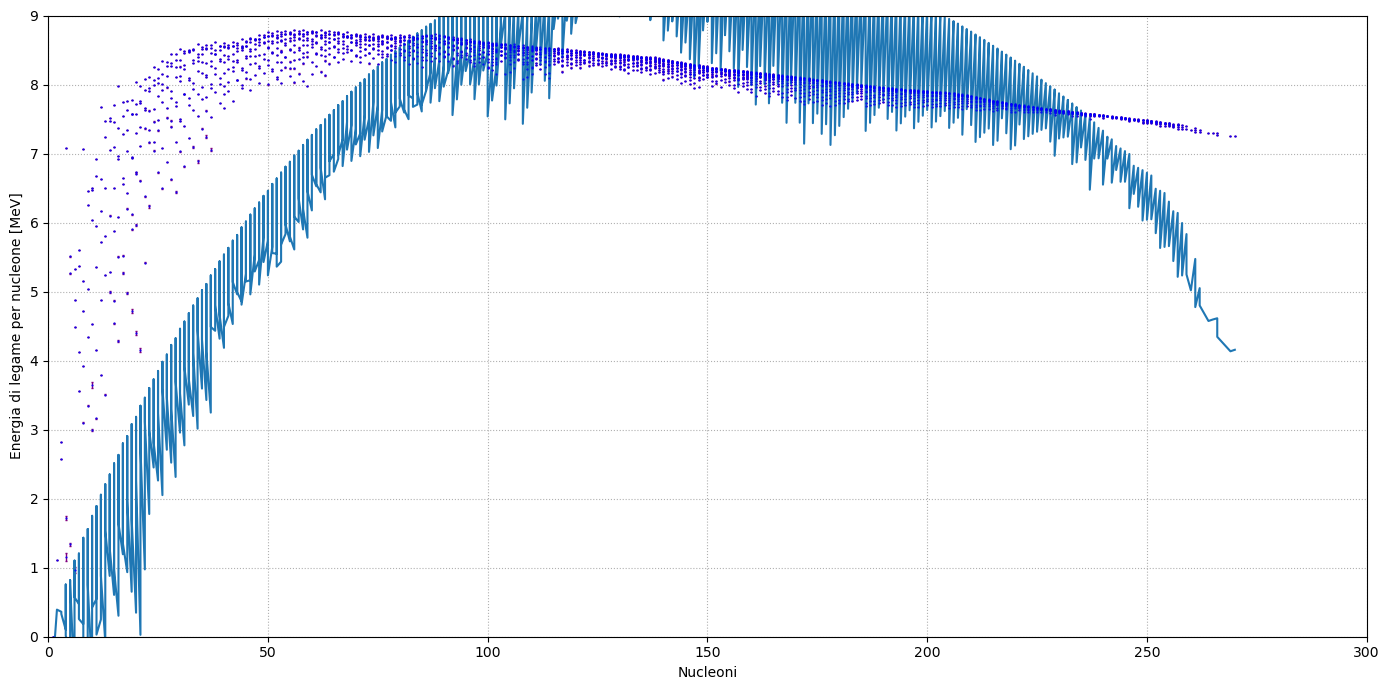

In [35]:
plt.figure(figsize = (14,7))
plt.errorbar(data["A"], data["binding_energy"]*1e-3, yerr = data["binding_energy_err"]*1e-3,
             fmt = ".", ms=1, color="b", elinewidth=1, ecolor = "purple", capsize = 1)
model = 0.197 * A - 0.001 * A23 - 0.023 * ZZ - 0.683 * NZ
plt.plot(data["A"], model)
plt.xlabel("Nucleoni")
plt.ylabel("Energia di legame per nucleone [MeV]")
plt.xlim(0,300)
plt.ylim(0,9)
plt.grid(linestyle = ":")
plt.tight_layout()
plt.show()

# DA QUESTO TEST È EVIDENTE CHE ULTRANEST NON STIA FUNZIONANDO

# Ultranest per forma tradizionale (con pairing)

In [13]:
# Iniziamo coi soliti calcoli preliminari fuori dalle funzioni:

A = data["A"].to_numpy(dtype=float)
Z = data["Z"].to_numpy(dtype=float)
N = data["N"].to_numpy(dtype=float)
BE = data["binding_energy"].to_numpy(dtype=float) * 1e-3
sigma_exp_sq = (data["binding_energy_err"].to_numpy(dtype=float) * 1e-3)**2
A23 = A**(2/3)
A13 = A**(1/3)
ZZ = Z*(Z-1) / A13
NZ = (N-Z)**2 / A
ln_2pi = np.log(2*np.pi)


# Ma il punto è che ora il guadagno di performance lo troviamo calcolando anche il termine di pairing fuori:
even_A = (A % 2 == 0)
even_Z = (Z % 2 == 0)
even_N = (N % 2 == 0) # Questi sono vettori di True e False a seconda se sia soddisfatta la condizione o meno nelle posizioni corrispondenti

pairing = np.where(even_Z & even_N, -1.0, np.where((~even_Z) & (~even_N), 1.0, 0.0))
# Nota che np.where può essere nested dentro sé stesso, e nota che ~ corrisponde a "not" per vettori di bit (non chiedermi perché).
# Nota anche che stiamo usando la convenzione che even-even ha il meno mentre odd-odd ha il più.
A34 = A**(3/4)
pairing /= A34


# Ricordiamoci dei bound:
lower_bounds = np.array([0, 0, 0, 0, 0, 0], dtype=float)
upper_bounds = np.array([1, 1, 1, 1, 10, 1], dtype=float)


# Quindi ora scriviamo nuovi likelihood e prior:

def ln_likelihood_pairing(parameters):
    aV = parameters[:, 0]
    aS = parameters[:, 1]
    aC = parameters[:, 2]
    aA = parameters[:, 3]
    aP = parameters[:, 4]
    ln_eps = parameters[:, 5]

    sigma_teo_sq = np.exp(2.0*ln_eps)
    sigma_tot_sq = sigma_exp_sq[None, :] + sigma_teo_sq[:, None]

    model = aV[:,None] * A - aS[:,None] * A23 - aC[:,None] * ZZ - aA[:,None] * NZ - aP[:,None] * pairing

    return -0.5 * np.sum( ln_2pi + np.log(sigma_tot_sq) + (BE[None,:] - model)**2.0 / sigma_tot_sq , axis=1)

def prior_pairing(cube):
    return cube * (upper_bounds - lower_bounds) + lower_bounds


In [15]:
# Svolgiamo la run per il caso pairing:

list_of_params = ["aV", "aS", "aC", "aA", "aP", "ln_epsilon"]
sampler = ultranest.ReactiveNestedSampler(list_of_params, ln_likelihood_pairing, prior_pairing, vectorized=True)
result_pairing = sampler.run()

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-5e+03  980.33 [-4980.8987..-4980.8983]*| it/evals=13720/76626 eff=17.9991% N=400   0      0 
[ultranest] Likelihood function evaluations: 76839
[ultranest]   logZ = -5011 +- 0.2042
[ultranest] Effective samples strategy satisfied (ESS = 2693.8, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.04 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.14 to 0.68, need <0.5)
[ultranest]   logZ error budget: single: 0.26 bs:0.20 tail:0.01 total:0.20 required:<0.50
[ultranest] done iterating.


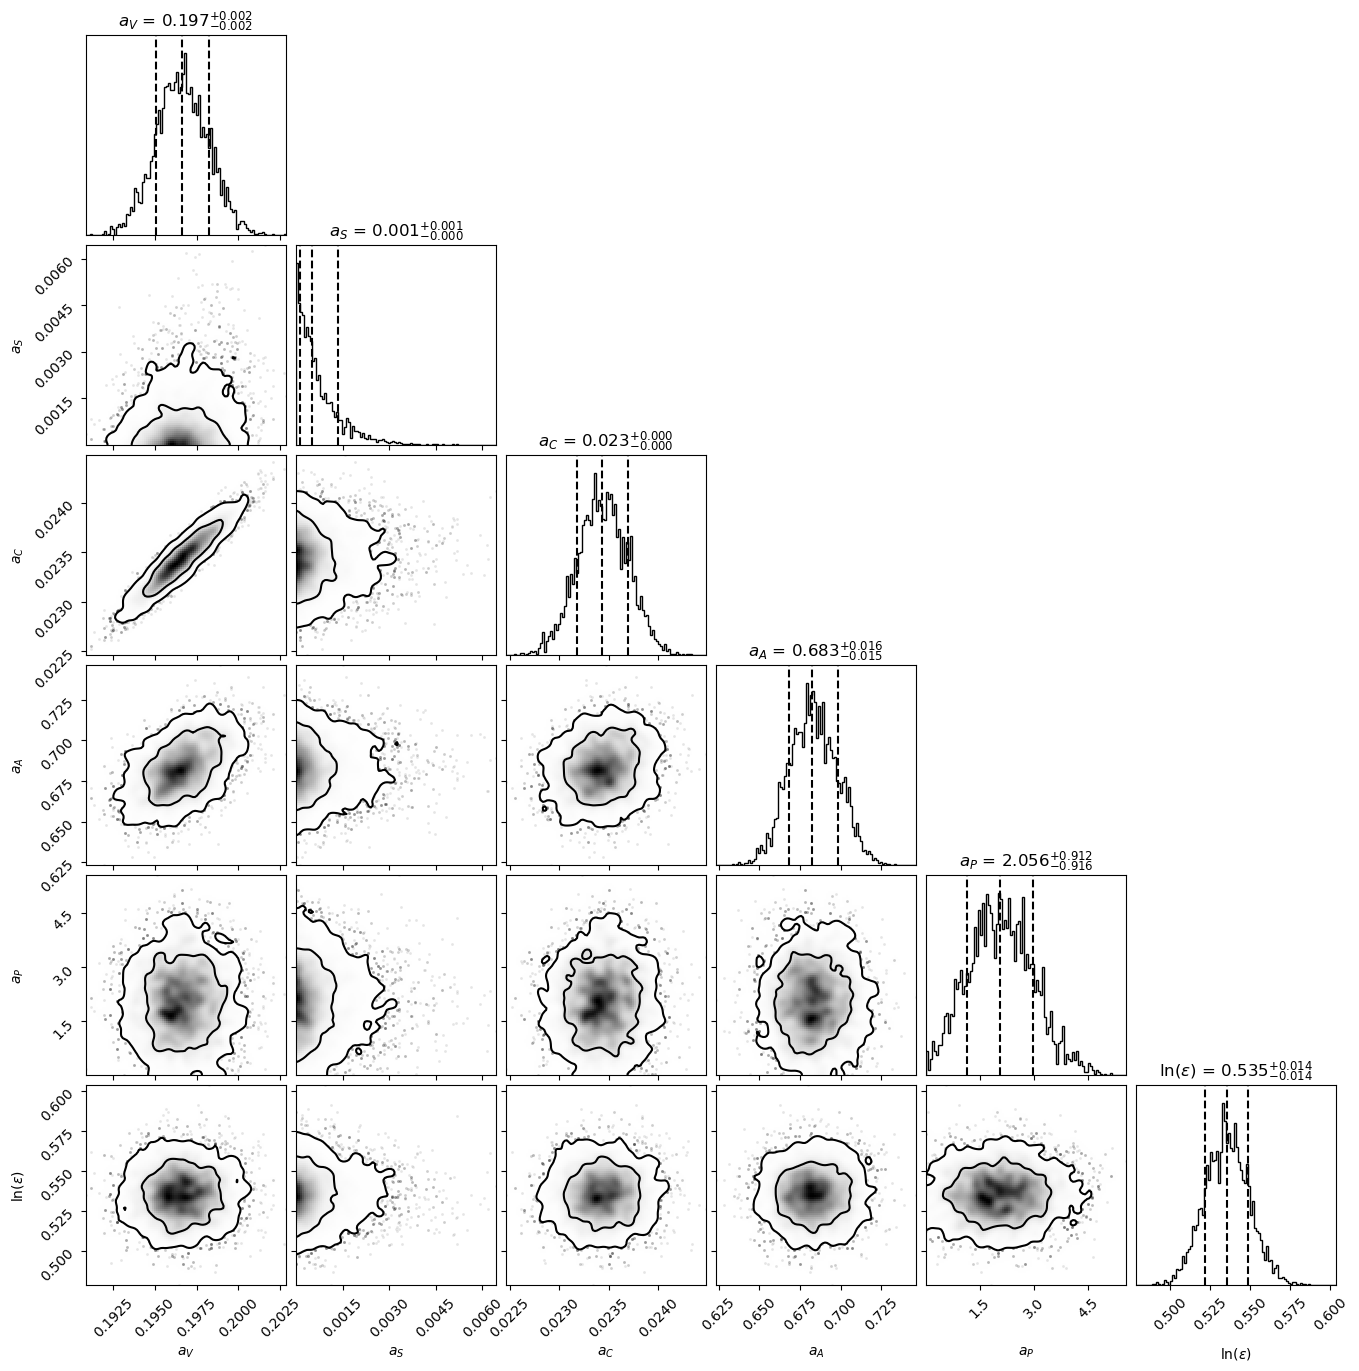

In [17]:
# Facciamo i corner plot:

samples_pairing = result_pairing["samples"]
labels = [r"$a_V$", r"$a_S$", r"$a_C$", r"$a_A$", r"$a_P$", r"$\ln (\epsilon)$"]

figure = corner.corner(
    samples_pairing,
    labels=labels,
    show_titles=True,           
    title_kwargs={"fontsize": 12},
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84],   
    plot_datapoints=True,
    bins=100,
    smooth=2.0,
    levels=(0.68, 0.95)
    #fill_contours=True,        
    #color="royalblue"                
)

axes = figure.axes